## Imports

In [1]:
from gvxrPython3 import gvxr 
from gvxrPython3.utils import  loadSpekpySpectrum
import ipynbname
import os
import numpy as np
from PIL import Image
import sys

import matplotlib.pyplot as plt 
from pathlib import Path


path = ipynbname.path()
BASE = path.parents[2] 

sys.path.append(str(BASE))
from Classes.Nanotom_class.NanotomXCT import NanotomXCT
from Classes.Comparisor_class.xct_comparisor import *
path_data = BASE / "Data/Al_crucible"
path_results = BASE / "Results/Legoman2"

if not os.path.exists(path_results):
    os.makedirs(path_results)


## Cropping function

In [2]:
def crop_pixels(img, top=0, bottom=0, left=0, right=0):
    """
    Crop an image by removing a specific number of pixels
    from each side.

    Args:
        img: NumPy array (H, W) or (H, W, C)
        top, bottom, left, right: number of pixels to remove

    Returns:
        Cropped NumPy array
    """
    H, W = img.shape[:2]

    # Clamp values to avoid empty or inverted images
    top = min(max(top, 0), H)
    bottom = min(max(bottom, 0), H - top)
    left = min(max(left, 0), W)
    right = min(max(right, 0), W - left)

    return img[top:H-bottom, left:W-right, ...]

## Acquisition settings

In [13]:
SDD=499.99690000
SSD=24.99990000

voltage_kV = 60
current_mA = 0.3 
exposure_time_s = 0.375013 

# Number of pixels 
xPixels = 2048
yPixels = 1000
pixel_size = 0.1

scaling = 1
lenght_unit = "mm"

tom = NanotomXCT(length_unit=lenght_unit, scaling=scaling, output_path=path_data)
tom.set_distances(SSD=SSD, SDD=SDD)

optimized = True

if optimized:
    tom.setup_detector(xPixels=xPixels, yPixels=yPixels)
    tom.setup_source(voltage_kV=voltage_kV, current_mA=current_mA, exposure_time_s=exposure_time_s, noise=True)
else:
    tom.setup_detector(xPixels=xPixels, yPixels=yPixels, scintillator=None)
    tom.setup_source(voltage_kV=voltage_kV, current_mA=current_mA, exposure_time_s=exposure_time_s, noise=True, filter=None)

s = sp.Spek(kvp= 60 , th= 12 , mas= 0.11250389999999999 , z= 49.999691009521484
380489408.76962674  photons / cm^2
38048.94144393608  photons / pixel


## Loading mesh and applying material composition

In [14]:
gvxr.removePolygonMeshesFromSceneGraph()
density_body = 1.04
mesh_Al = path_data / "Mesh" / "Al crucible mesh.stl"
tom.addMesh("Al_crucible", mesh_Al, gvxr.getDensityFromElement("Al"),element="Al")           

### density of aluminium

In [5]:
print(gvxr.getDensity("Al_crucible"))

2.698


## Generating simulated projection and comparing to experimental projection

RMSE: 0.011782618
SSIM: 0.8841301265606697
HI: 0.9241689482089893


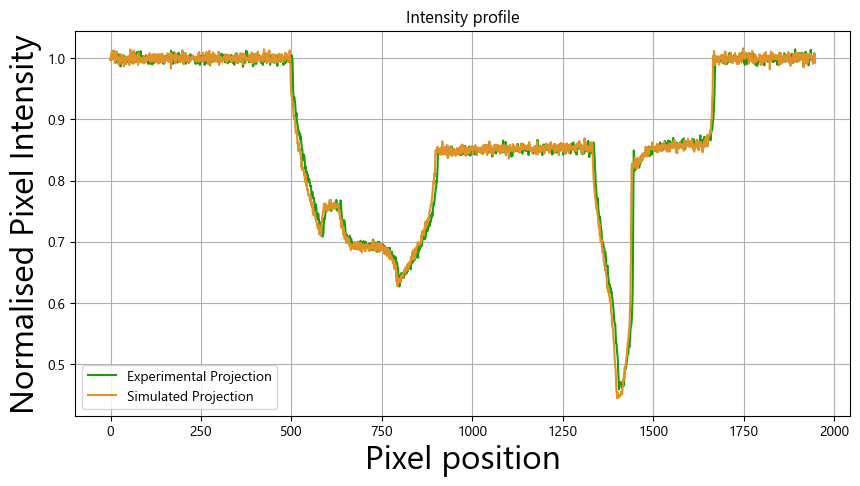

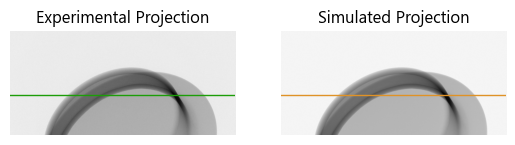

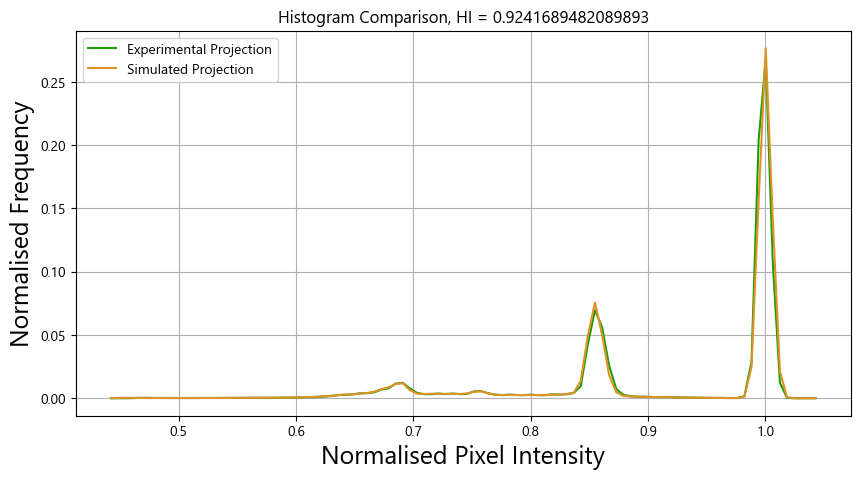

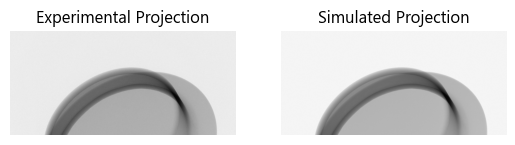

In [15]:
img_sim = tom.compute2D() 

img_org = get_org_projection(path_data/ f"Projections/Al crucible_300001.tif", flip=True)
white_value = img_org[:10,:].mean()
img_org /= white_value

img_org = crop_pixels(img_org, 0, 100, 50, 50)
img_sim = crop_pixels(img_sim, 0, 100, 50, 50)

get_metrics(img_sim, img_org)
two_line_plot(img_sim, img_org, 550)
histogram_plot(img_sim, img_org)

plt.figure()
plt.subplot(1,2,1)
plt.imshow(img_org, cmap='gray')
plt.axis('off')
plt.title("Experimental Projection")

plt.subplot(1,2,2)
plt.imshow(img_sim, cmap='gray')
plt.axis('off')
plt.title("Simulated Projection")
plt.savefig(path_results / f"Images")
plt.show()


## Generating metrics and figures for multple projections

Projection number: 1


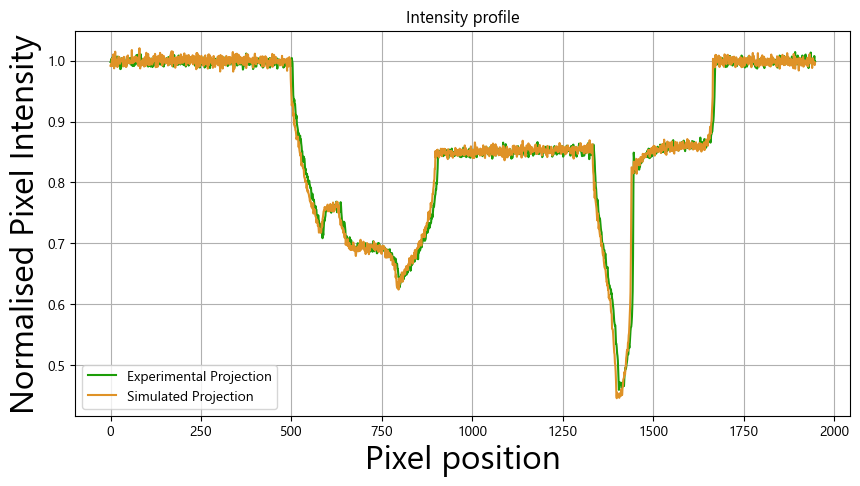

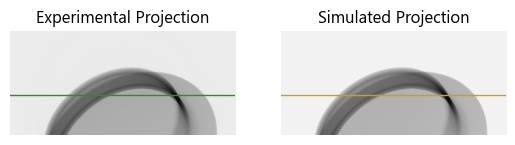


RMSE: 0.011929783
SSIM: 0.8741219626392679
HI: 0.9245670773442847
Projection number: 200


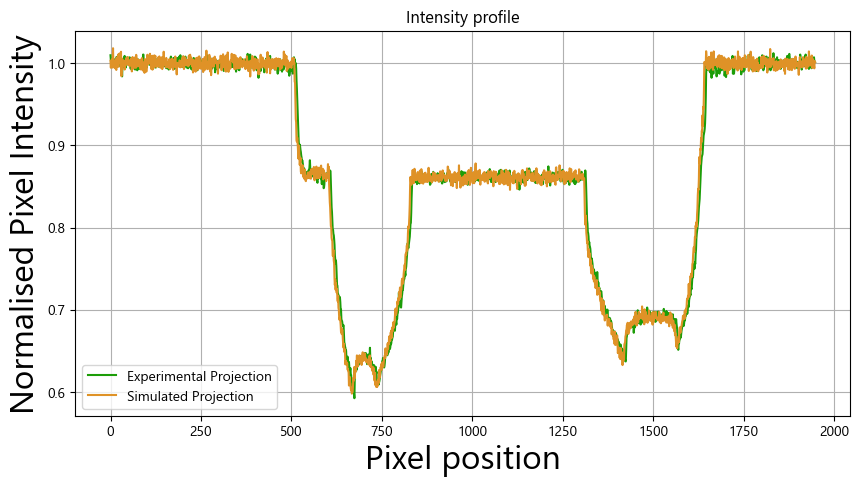

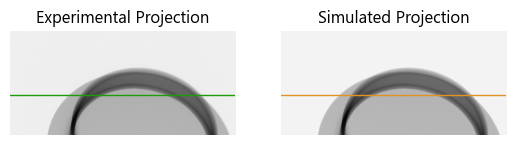


RMSE: 0.012371112
SSIM: 0.8610971272967239
HI: 0.9263843258042436
Projection number: 400


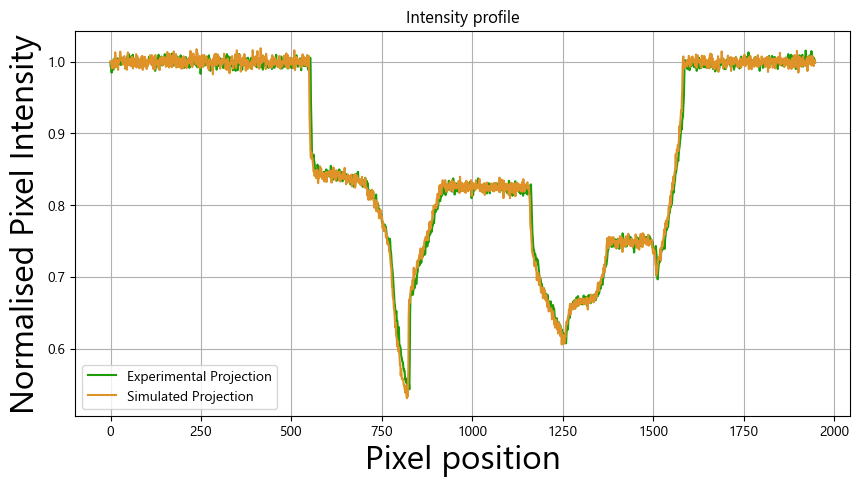

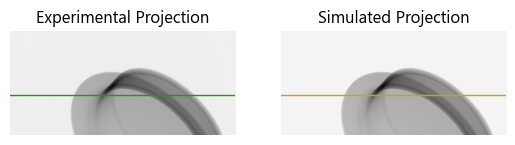


RMSE: 0.01002836
SSIM: 0.8911181522553775
HI: 0.9429340634268767
Projection number: 600


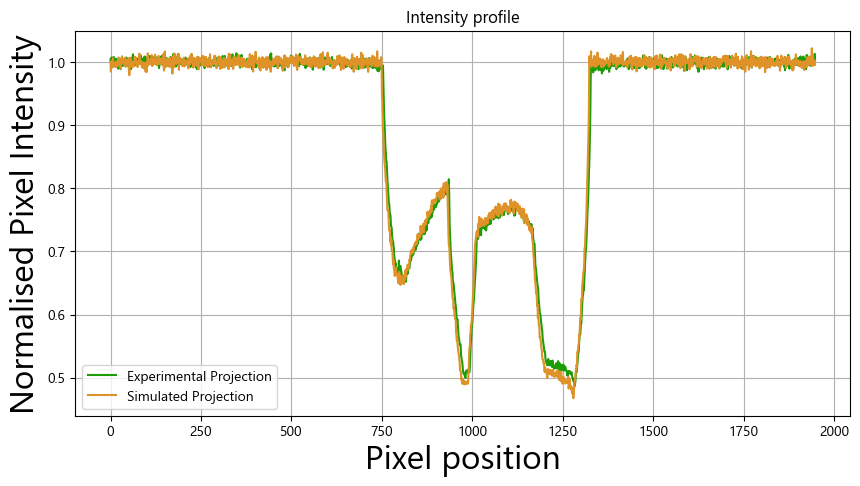

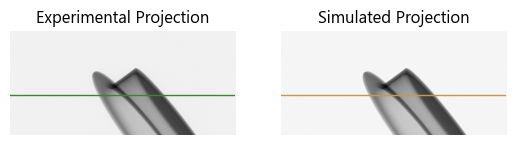


RMSE: 0.013530288
SSIM: 0.9054188189646286
HI: 0.9002754962354552
Projection number: 800


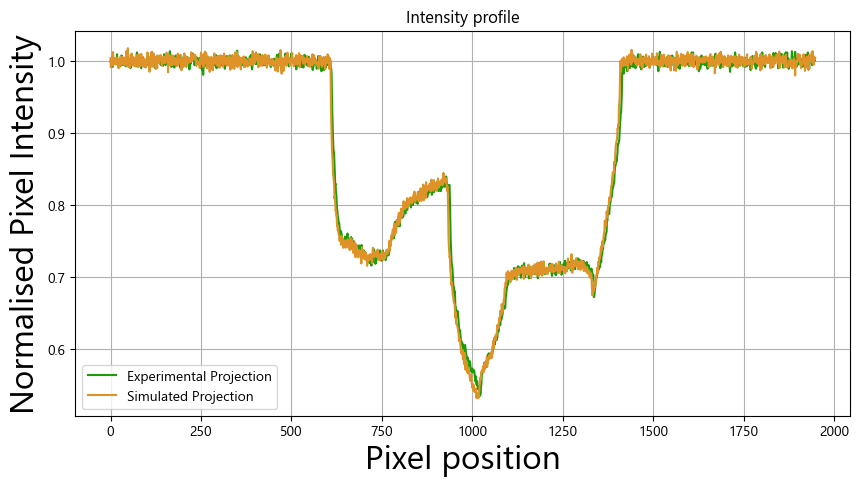

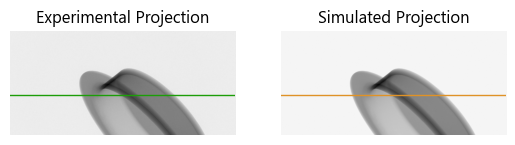


RMSE: 0.010038404
SSIM: 0.8974195698294888
HI: 0.9220704996577687
Projection number: 1000


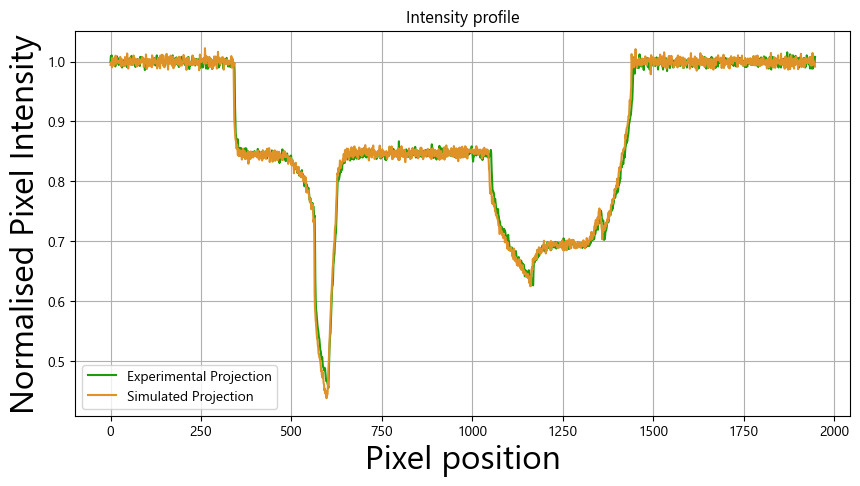

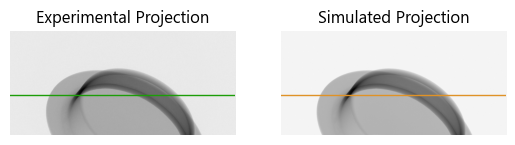


RMSE: 0.0093897255
SSIM: 0.8861574519640878
HI: 0.9217094455852156
Projection number: 1200


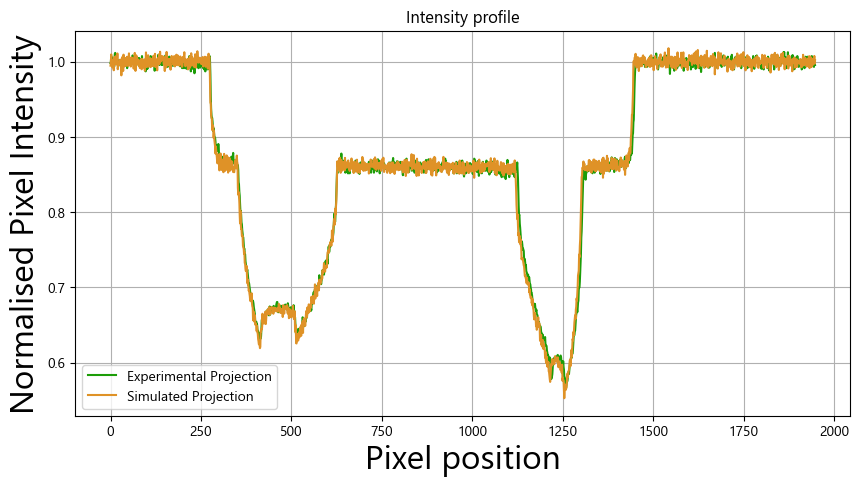

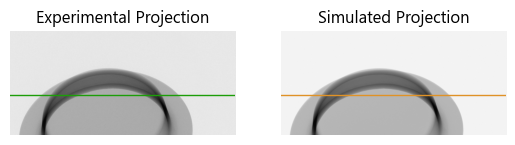


RMSE: 0.010493387
SSIM: 0.8769709483124382
HI: 0.9051437371663245
Projection number: 1400


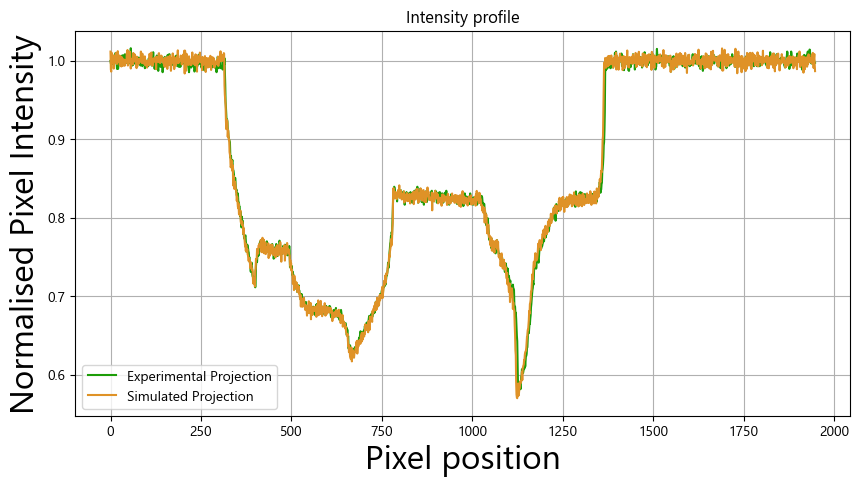

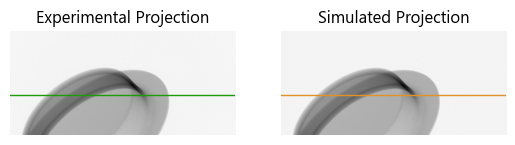


RMSE: 0.0092730755
SSIM: 0.8909065943305744
HI: 0.9449509468400639
Projection number: 1600


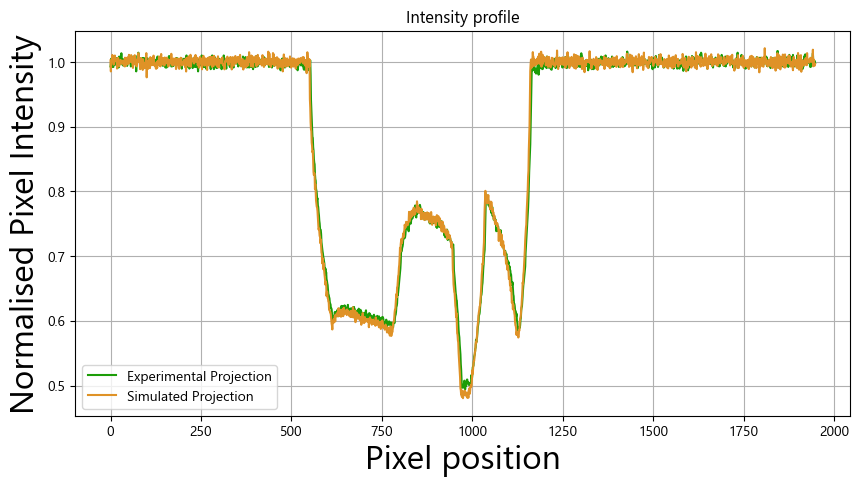

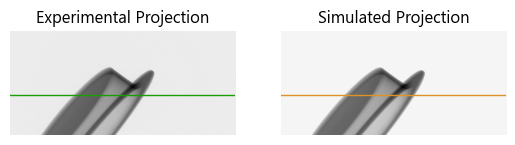


RMSE: 0.012160653
SSIM: 0.9101909358935409
HI: 0.9099047456080311
Projection number: 1800


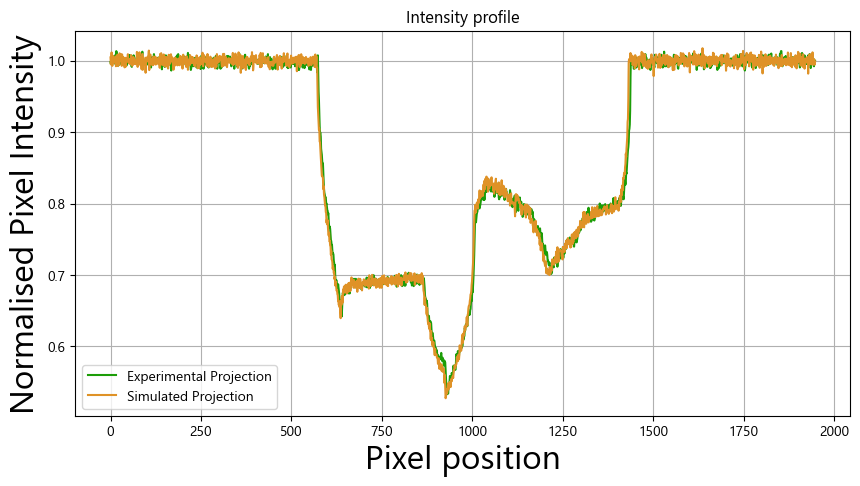

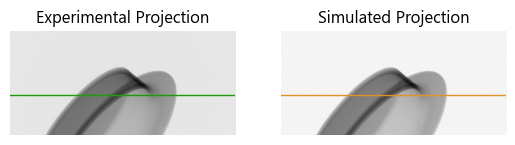


RMSE: 0.011258028
SSIM: 0.9005327623818767
HI: 0.9310312571298198
Average HI = 0.9228971594798084
Average RMSE = 0.011047281604260207


In [16]:
sum_hi = 0
sum_rmse = 0
path = "D:/Al_crucible/CT_2000_FCC=5"
real_projections_path = path_data/ f"Projections/"

for i in range(0,10,1):
    k = (i * 200)
    if k == 0:
        sim_proj = np.array(Image.open(path + f"/Projections/projection_000{k}.tiff"), dtype=np.single)#/ gvxr.getTotalEnergyWithDetectorResponse()
    elif n < 1000:
        sim_proj = np.array(Image.open(path + f"/Projections/projection_0{k-1}.tiff"), dtype=np.single)#/ gvxr.getTotalEnergyWithDetectorResponse()
    else:
        sim_proj = np.array(Image.open(path + f"/Projections/projection_{k-1}.tiff"), dtype=np.single)#/ gvxr.getTotalEnergyWithDetectorResponse()

    sim_proj = crop_pixels(sim_proj, 0, 100, 50, 50)

    n = k
    if k == 0:
        n = k+1
        real_file = f"Al crucible_30000{n}.tif"
    elif n < 1000:
        real_file = f"Al crucible_300{n}.tif"
    else:
        real_file = f"Al crucible_30{n}.tif"

    real_proj = get_org_projection(real_projections_path/ real_file, scaling=scaling, flip=True)
    white_value = real_proj[:10,:].mean()
    real_proj /= white_value
    real_proj = crop_pixels(real_proj, 0, 100, 50, 50)

    images = {"Real Projection": real_proj,
          "Simulated Projection": sim_proj}
    
    print("Projection number: " + str(n))   
    two_line_plot(sim_proj, real_proj, 550)
    sum_hi += hi(real_proj, sim_proj)
    sum_rmse += rmse(real_proj, sim_proj)
    get_metrics(real_proj, sim_proj, "")

print("Average HI = " + str(sum_hi/10))
print("Average RMSE = " + str(sum_rmse/10))